### load feature

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

model_name = "FVs_medsiglip"

npz_path = f"./aligned_features_all/aligned_all_{model_name}.npz"
meta_path = f"./aligned_features_all/aligned_all_{model_name}_metadata.csv"

data = np.load(npz_path, allow_pickle=True)
X = data["X"]

meta_df = pd.read_csv(meta_path)

print("X:", X.shape)
print("metadata:", meta_df.shape)
display(meta_df.head())
meta_df["eye_DR_Level"].value_counts().sort_index()

X: (1200, 1152)
metadata: (1200, 12)


,patient_id,image_id,image_path,Overall quality,left_eye_DR_Level,right_eye_DR_Level,patient_DR_Level,Clarity,Field definition,Artifact,eye,eye_DR_Level
0,1,1_l1,\regular-fundus-training\1\1_l1.jpg,0,0.0,NaN,0,8,8,4,l,0.0
1,1,1_l2,\regular-fundus-training\1\1_l2.jpg,0,0.0,NaN,0,8,8,0,l,0.0
2,1,1_r1,\regular-fundus-training\1\1_r1.jpg,0,NaN,0.0,0,8,8,4,r,0.0
3,1,1_r2,\regular-fundus-training\1\1_r2.jpg,0,NaN,0.0,0,10,8,0,r,0.0
4,2,2_l1,\regular-fundus-training\2\2_l1.jpg,0,2.0,NaN,2,10,8,6,l,2.0


eye_DR_Level
0.0    532
1.0    139
2.0    232
3.0    214
4.0     72
Name: count, dtype: int64

### PCA

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 标准化
X_raw = X.copy() 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# PCA
n_components = 50
pca = PCA(n_components, random_state=0)
Z = pca.fit_transform(X_scaled)

print("PCA result:", Z.shape)
print("Explained variance ratio:")
display(pca.explained_variance_ratio_[:10])
print("Cumulative explained variance:")
display(np.cumsum(pca.explained_variance_ratio_)[:10])

PCA result: (1200, 50)
Explained variance ratio:


array([0.1687902 , 0.12890346, 0.08817758, 0.07440851, 0.04612817,
       0.03619927, 0.0346098 , 0.02859543, 0.02539492, 0.02172936],
      dtype=float32)

Cumulative explained variance:


array([0.1687902 , 0.29769367, 0.38587123, 0.46027973, 0.5064079 ,
       0.5426072 , 0.577217  , 0.60581243, 0.63120735, 0.6529367 ],
      dtype=float32)

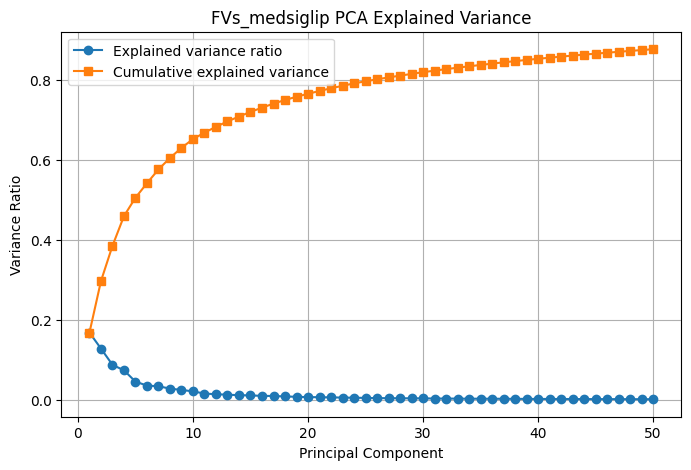

In [12]:
explained = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained)

plt.figure(figsize=(8, 5))
plt.plot(range(1, n_components + 1), explained, marker="o", label="Explained variance ratio")
plt.plot(range(1, n_components + 1), cum_explained, marker="s", label="Cumulative explained variance")
plt.xlabel("Principal Component")
plt.ylabel("Variance Ratio")
plt.title(f"{model_name} PCA Explained Variance")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
pca_df = meta_df.copy()

for i in range(Z.shape[1]):
    pca_df[f"PC{i+1}"] = Z[:, i]

display(pca_df.head())

,patient_id,image_id,image_path,Overall quality,left_eye_DR_Level,right_eye_DR_Level,patient_DR_Level,Clarity,Field definition,Artifact,...,PC41,PC42,PC43,PC44,PC45,PC46,PC47,PC48,PC49,PC50
0,1,1_l1,\regular-fundus-training\1\1_l1.jpg,0,0.0,NaN,0,8,8,4,...,-0.135991,1.762665,0.479233,1.536205,2.333333,-1.342776,0.178623,0.557654,1.137488,0.377065
1,1,1_l2,\regular-fundus-training\1\1_l2.jpg,0,0.0,NaN,0,8,8,0,...,0.004276,-0.132709,0.015512,2.298479,-0.563633,-0.427537,0.479258,-0.714359,1.661108,-1.250896
2,1,1_r1,\regular-fundus-training\1\1_r1.jpg,0,NaN,0.0,0,8,8,4,...,0.060349,0.135745,2.658953,-0.009553,-1.430878,-1.464769,0.456400,-1.517892,0.977249,-2.274666
3,1,1_r2,\regular-fundus-training\1\1_r2.jpg,0,NaN,0.0,0,10,8,0,...,-2.534301,0.467129,0.635711,2.101113,-0.211326,-0.471925,-0.115268,0.215969,1.065533,-3.061199
4,2,2_l1,\regular-fundus-training\2\2_l1.jpg,0,2.0,NaN,2,10,8,6,...,0.261491,-0.342077,-2.401546,0.996827,1.695114,0.288146,-0.941123,-1.258714,-1.033130,-0.315750


### 